In [11]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.random.seed(42)

In [12]:
def train_val_test_split(X, y):
    n = len(X)
    idx = np.random.permutation(n)
    X, y = X[idx], y[idx]

    n_train = int(0.7 * n)
    n_val = int(0.15 * n)

    X_train = X[:n_train]
    y_train = y[:n_train]

    X_val = X[n_train:n_train+n_val]
    y_val = y[n_train:n_train+n_val]

    X_test = X[n_train+n_val:]
    y_test = y[n_train+n_val:]

    return X_train, y_train, X_val, y_val, X_test, y_test


def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def relu(z):
    return np.maximum(0, z)


def drelu(z):
    return (z > 0).astype(float)


def dsigmoid(a):
    return a * (1 - a)


def binary_cross_entropy(y_hat, y):
    eps = 1e-8
    y_hat = np.clip(y_hat, eps, 1-eps)
    return -np.mean(y*np.log(y_hat) + (1-y)*np.log(1-y_hat))


def accuracy(y_hat, y):
    preds = (y_hat >= 0.5).astype(int)
    return np.mean(preds == y)

In [13]:
class DenseNetwork:
    def __init__(self, layer_sizes, activation='relu'):
        self.L = len(layer_sizes) - 1
        self.activation_name = activation
        self.params = {}
        self.velocity = {}
        self.m = {}
        self.v = {}

        for l in range(1, self.L+1):
            self.params['W'+str(l)] = np.random.randn(
                layer_sizes[l-1], layer_sizes[l]
            ) * np.sqrt(2/layer_sizes[l-1])
            self.params['b'+str(l)] = np.zeros((1, layer_sizes[l]))

            self.velocity['W'+str(l)] = np.zeros_like(self.params['W'+str(l)])
            self.velocity['b'+str(l)] = np.zeros_like(self.params['b'+str(l)])
            self.m['W'+str(l)] = np.zeros_like(self.params['W'+str(l)])
            self.m['b'+str(l)] = np.zeros_like(self.params['b'+str(l)])
            self.v['W'+str(l)] = np.zeros_like(self.params['W'+str(l)])
            self.v['b'+str(l)] = np.zeros_like(self.params['b'+str(l)])

    def activation(self, z):
        return sigmoid(z) if self.activation_name=='sigmoid' else relu(z)

    def dactivation(self, a):
        return dsigmoid(a) if self.activation_name=='sigmoid' else drelu(a)

    def forward(self, X):
        cache = {'A0': X}
        A = X
        for l in range(1, self.L):
            Z = A @ self.params['W'+str(l)] + self.params['b'+str(l)]
            A = self.activation(Z)
            cache['Z'+str(l)] = Z
            cache['A'+str(l)] = A

        ZL = A @ self.params['W'+str(self.L)] + self.params['b'+str(self.L)]
        AL = sigmoid(ZL)

        cache['Z'+str(self.L)] = ZL
        cache['A'+str(self.L)] = AL

        return AL, cache

    def backward(self, y_hat, y, cache):
        grads = {}
        m = y.shape[0]
        dA = y_hat - y.reshape(-1,1)

        for l in reversed(range(1, self.L+1)):
            A_prev = cache['A'+str(l-1)]
            dW = (A_prev.T @ dA) / m
            db = np.mean(dA, axis=0, keepdims=True)

            grads['dW'+str(l)] = dW
            grads['db'+str(l)] = db

            if l > 1:
                dA = dA @ self.params['W'+str(l)].T
                dA *= self.dactivation(cache['A'+str(l-1)])

        return grads

    def update(self, grads, lr, optimizer='sgd', beta=0.9,
               beta1=0.9, beta2=0.999, eps=1e-8, t=1):

        for l in range(1, self.L+1):

            if optimizer == 'sgd':
                self.params['W'+str(l)] -= lr * grads['dW'+str(l)]
                self.params['b'+str(l)] -= lr * grads['db'+str(l)]

            elif optimizer == 'momentum':
                self.velocity['W'+str(l)] = beta*self.velocity['W'+str(l)] + lr*grads['dW'+str(l)]
                self.velocity['b'+str(l)] = beta*self.velocity['b'+str(l)] + lr*grads['db'+str(l)]

                self.params['W'+str(l)] -= self.velocity['W'+str(l)]
                self.params['b'+str(l)] -= self.velocity['b'+str(l)]

            elif optimizer == 'adam':
                self.m['W'+str(l)] = beta1*self.m['W'+str(l)] + (1-beta1)*grads['dW'+str(l)]
                self.v['W'+str(l)] = beta2*self.v['W'+str(l)] + (1-beta2)*(grads['dW'+str(l)]**2)

                m_hat = self.m['W'+str(l)]/(1-beta1**t)
                v_hat = self.v['W'+str(l)]/(1-beta2**t)

                self.params['W'+str(l)] -= lr*m_hat/(np.sqrt(v_hat)+eps)

In [14]:
def generate_numeric_data(N=3000):
    x1 = np.random.uniform(-2,2,N)
    x2 = np.random.uniform(-2,2,N)
    y = (x1**2 + x2**2 > 1.5).astype(int)
    X = np.column_stack((x1,x2))
    return X, y

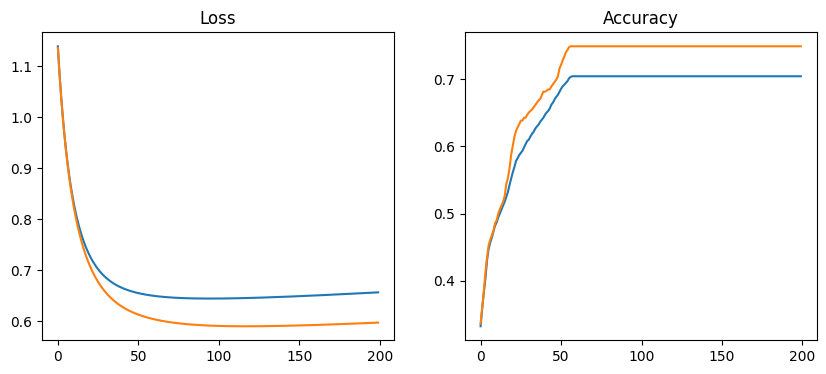

Test Accuracy: 0.74
Test Loss: 0.6171350597552429


In [15]:
X, y = generate_numeric_data(3000)
X_train, y_train, X_val, y_val, X_test, y_test = train_val_test_split(X, y)

model = DenseNetwork([2, 8, 1], activation='relu')

epochs = 200
lr = 0.05

train_loss = []
val_loss = []
train_acc = []
val_acc = []

for epoch in range(epochs):

    y_pred, cache = model.forward(X_train)
    loss = binary_cross_entropy(y_pred, y_train)

    grads = model.backward(y_pred, y_train, cache)
    model.update(grads, lr, optimizer='sgd', t=epoch+1)

    val_pred, _ = model.forward(X_val)

    train_loss.append(loss)
    val_loss.append(binary_cross_entropy(val_pred, y_val))
    train_acc.append(accuracy(y_pred, y_train))
    val_acc.append(accuracy(val_pred, y_val))

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_loss)
plt.plot(val_loss)
plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(train_acc)
plt.plot(val_acc)
plt.title("Accuracy")

plt.show()

test_pred, _ = model.forward(X_test)

print("Test Accuracy:", accuracy(test_pred, y_test))
print("Test Loss:", binary_cross_entropy(test_pred, y_test))